# Imports

In [1]:
# Imports
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import glob


# Data load from Github

In [2]:
#Cloning repo from Github
!git clone https://github.com/OPIM5512-qxa24002/myscrapers-qxa24002-v1.git
%cd myscrapers-qxa24002-v1

Cloning into 'myscrapers-qxa24002-v1'...
remote: Enumerating objects: 671, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 671 (delta 85), reused 33 (delta 18), pack-reused 565 (from 2)
Receiving objects: 100% (671/671), 799.96 KiB | 7.08 MiB/s, done.
Resolving deltas: 100% (287/287), done.
/content/myscrapers-qxa24002-v1


In [3]:
# Load training data from Github
df = pd.read_csv("data/listings_master_llm.csv")
df.tail()


,post_id,run_id,scraped_at,price,year,make,model,mileage,transmission,fuel_type,drive_type,vehicle_type,color,condition,title_status,source_txt
1052,7925306944,20260403100047,2026-04-03T10:00:47Z,12850.0,2016,Dodge,Grand Caravan,48019.0,automatic,gas,fwd,minivan,blue,Used,clean,scrapes/20260403100047/7925306944.txt
1053,7925305513,20260403110007,2026-04-03T11:00:07Z,16900.0,2017,Land Rover,Range Rover Sport,95262.0,automatic,gas,NaN,SUV,black,Used,clean,scrapes/20260403110007/7925305513.txt
1054,7925305585,20260403130050,2026-04-03T13:00:50Z,12300.0,2014,Ford,Econoline Cargo Van e-250,91374.0,automatic,gas,fwd,van,Oxford White,Used,clean,scrapes/20260403130050/7925305585.txt
1055,7925306888,20260403130050,2026-04-03T13:00:50Z,14850.0,2020,Ford,Fusion,35125.0,automatic,gas,fwd,sedan,blue,Used,clean,scrapes/20260403130050/7925306888.txt
1056,7925331759,20260403130050,2026-04-03T13:00:50Z,3200.0,2014,Subaru,legacy 2.5i premium,212700.0,automatic,gas,NaN,sedan,blue,excellent,clean,scrapes/20260403130050/7925331759.txt


In [4]:
num_rows = len(df)
print(f"The listings_master_llm csv has {num_rows} rows.")

The listings_master_llm csv has 1057 rows.


In [5]:
#Basic Prep
def clean_numeric(s):
    s = s.astype(str).str.replace(r"[^\d.]+", "", regex=True).str.strip()
    return pd.to_numeric(s, errors="coerce")

# Define TIMEZONE
TIMEZONE = "America/New_York" # You can change this to your desired timezone

df["scraped_at_dt_utc"] = pd.to_datetime(df["scraped_at"], errors="coerce", utc=True)
df["scraped_at_local"] = df["scraped_at_dt_utc"].dt.tz_convert(TIMEZONE)
df["date_local"] = df["scraped_at_local"].dt.date

df["price_num"] = clean_numeric(df["price"])
df["year_num"] = clean_numeric(df["year"])
df["mileage_num"] = clean_numeric(df["mileage"])

df = df[df["price_num"].notna()].copy()

# Temporarily set display option to suppress scientific notation
pd.set_option('display.float_format', lambda x: '%.0f' % x)
df[["price_num", "year_num", "mileage_num"]].describe()
# Reset display option to default afterwards if needed
pd.reset_option('display.float_format')

### Scatter plot to show price and mileage relation

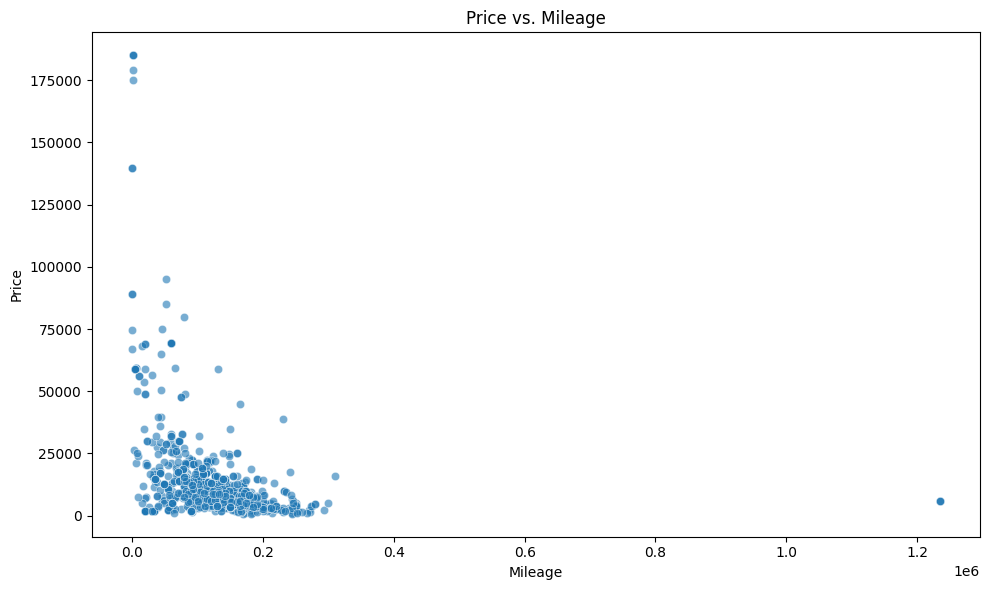

 Car price decreases with increase in mileage


In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage_num', y='price_num', data=df, alpha=0.6)
plt.title('Price vs. Mileage')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.tight_layout()
plt.show()
print(" Car price decreases with increase in mileage")

# Improved Model Creation

### Data splitting for training based on time

In [7]:
#Time-based split: use past data to predict today’s listings
unique_dates = sorted(d for d in df["date_local"].dropna().unique())
today_local = unique_dates[-1]

train_df = df[df["date_local"] < today_local].copy()
test_df = df[df["date_local"] == today_local].copy()

y_train = train_df["price_num"]
y_test = test_df["price_num"]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Today local:", today_local)

Train rows: 775
Test rows: 246
Today local: 2026-04-03


In [8]:
#Metrics helper
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results = {
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": rmse(y_test, preds),
        "MAPE": mape(y_test, preds),
        "Bias": bias(y_test, preds)
    }
    return model, preds, results

## Improved Model with Hyperparameter Training (GridSearchCV)


In [9]:
#Improved model
#features used : make, model, transmission, fuel_type, condition, title_status, color
improved_cat = [
    "make", "model", "transmission", "fuel_type",
    "condition", "title_status", "color"
]
improved_num = ["year_num", "mileage_num"]
improved_feats = improved_cat + improved_num

improved_pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), improved_num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), improved_cat),
    ]
)

improved_pipeline = Pipeline([
    ("pre", improved_pre),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# performing hyperparameter tuning for your Random Forest model!
# I am using GridSearchCV from scikit-learn, which systematically works through multiple combinations
#of hyperparameters as defined in param_grid to find the best performing set.
#The hyperparameters being tuned are n_estimators, max_depth,
# and min_samples_leaf for your RandomForestRegressor

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [2, 5, 10]
}

grid = GridSearchCV(
    improved_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

X_train_imp = train_df[improved_feats]
X_test_imp = test_df[improved_feats]

grid.fit(X_train_imp, y_train)

best_improved_model = grid.best_estimator_
improved_preds = best_improved_model.predict(X_test_imp)

improved_results = {
    "model": "Improved Random Forest",
    "MAE": mean_absolute_error(y_test, improved_preds),
    "RMSE": rmse(y_test, improved_preds),
    "MAPE": mape(y_test, improved_preds),
    "Bias": bias(y_test, improved_preds)
}

print("Best params:", grid.best_params_)
improved_results

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}


{'model': 'Improved Random Forest',
 'MAE': 4117.2202570636155,
 'RMSE': np.float64(8643.480588438504),
 'MAPE': np.float64(60.93803439977784),
 'Bias': np.float64(245.42766028069002)}

## Loading Baseline model outputs from Github

In [10]:
result_files = sorted(glob.glob("results/*-preds.csv"))
result_files[:5], len(result_files)

(['results/2026040220-preds.csv',
  'results/2026040221-preds.csv',
  'results/2026040222-preds.csv',
  'results/2026040300-preds.csv',
  'results/2026040303-preds.csv'],
 21)

# Model Performance & Model Accuracy

## Comparing Baseline and Improved Models

In [11]:
def extract_run_id_from_filename(filename):
    # Extract the base filename (e.g., '2026040220-preds.csv')
    base_name = filename.split('/')[-1]
    # Extract the run_id part (e.g., '2026040220')
    run_id = base_name.split('-')[0]
    return run_id

In [12]:
trend_rows = []

for file in result_files:
    run_id = extract_run_id_from_filename(file)
    res = pd.read_csv(file)

    # standardize numeric columns
    if "actual_price" not in res.columns or "pred_price" not in res.columns:
        continue

    res["actual_price"] = pd.to_numeric(res["actual_price"], errors="coerce")
    res["pred_price"] = pd.to_numeric(res["pred_price"], errors="coerce")
    res["year_num"] = clean_numeric(res["year"])
    res["mileage_num"] = clean_numeric(res["mileage"])

    # keep only rows where actual baseline comparison is possible
    eval_df = res[res["actual_price"].notna()].copy()
    if eval_df.empty:
        continue

    # ensure improved model feature columns exist
    for col in improved_cat:
        if col not in eval_df.columns:
            eval_df[col] = np.nan

    X_eval = eval_df[improved_feats]
    improved_preds = best_improved_model.predict(X_eval)
    eval_df["improved_pred_price"] = improved_preds

    y_true = eval_df["actual_price"].values
    y_base = eval_df["pred_price"].values
    y_improved = eval_df["improved_pred_price"].values

    trend_rows.append({
        "run_id": run_id,
        "rows": len(eval_df),

        "baseline_MAE": mean_absolute_error(y_true, y_base),
        "baseline_RMSE": rmse(y_true, y_base),
        "baseline_MAPE": mape(y_true, y_base),
        "baseline_Bias": bias(y_true, y_base),

        "improved_MAE": mean_absolute_error(y_true, y_improved),
        "improved_RMSE": rmse(y_true, y_improved),
        "improved_MAPE": mape(y_true, y_improved),
        "improved_Bias": bias(y_true, y_improved),
    })

trend_df = pd.DataFrame(trend_rows).sort_values("run_id").reset_index(drop=True)
trend_df

,run_id,rows,baseline_MAE,baseline_RMSE,baseline_MAPE,baseline_Bias,improved_MAE,improved_RMSE,improved_MAPE,improved_Bias
0,2026040220,276,6157.138370,12276.633472,86.811238,571.040399,3818.446535,8377.590571,59.186054,160.467220
1,2026040221,278,6254.848129,12364.921257,86.608799,424.926475,3875.671649,8471.648030,59.007116,33.688691
2,2026040222,282,6172.787979,12155.209725,86.281854,369.395142,3773.418771,8221.040279,58.527283,10.448244
3,2026040300,288,6205.707986,12239.329755,86.747902,221.290972,3747.787511,8081.068307,58.440400,89.955571
4,2026040303,293,6188.778908,12258.797173,86.494684,262.762389,3703.314468,7974.153163,54.615922,185.228079
5,2026040305,48,4640.358333,9913.366411,63.235382,2673.457083,2235.731000,3448.988126,38.000003,851.795907
6,2026040307,124,6257.811613,12517.231754,83.516531,2460.449516,4198.059723,8067.031885,58.984967,748.854557
7,2026040309,177,5402.309548,10182.879806,75.274331,1595.710791,4121.462436,8638.039799,60.038094,959.051123
8,2026040310,193,5366.364352,10094.649548,76.363335,1287.219275,3909.453811,8296.852939,56.788839,838.303980
9,2026040311,212,5372.514953,9940.795784,73.239482,1008.725330,3878.528421,8259.941013,54.564264,605.617429




 ## Plotting Baseline and Improved Model Performance

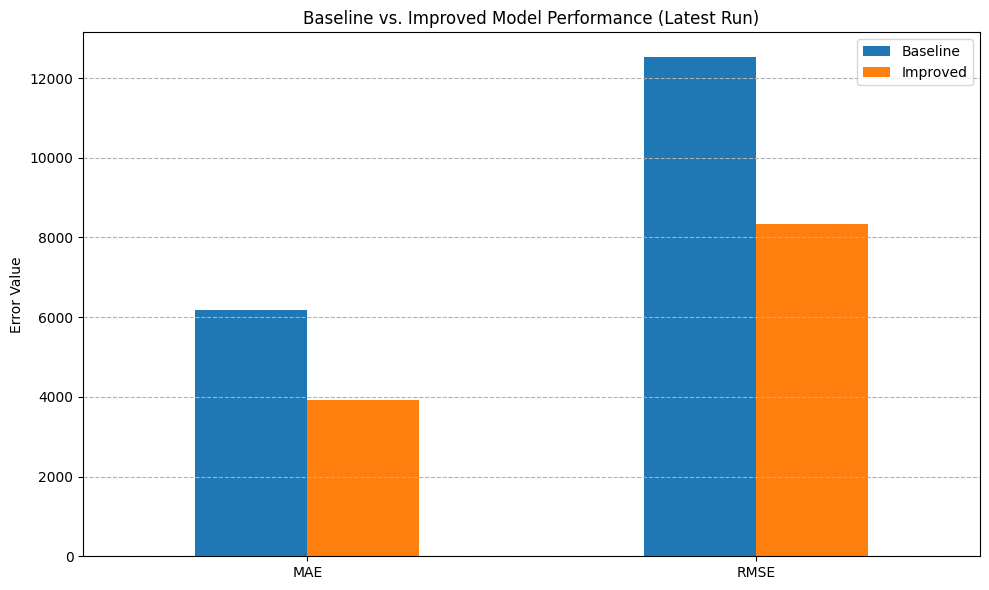

Percentage Improvement of Improved Model over Baseline:


,MAE,RMSE,MAPE,Bias
Percentage Improvement (%),36.486798,33.476683,34.402962,-36.956923


In [13]:
baseline_values = pd.Series(trend_df.iloc[-1][["baseline_MAE", "baseline_RMSE", "baseline_MAPE", "baseline_Bias"]].values, index=["MAE", "RMSE", "MAPE", "Bias"])
improved_values = pd.Series(trend_df.iloc[-1][["improved_MAE", "improved_RMSE", "improved_MAPE", "improved_Bias"]].values, index=["MAE", "RMSE", "MAPE", "Bias"])

comparison = pd.DataFrame({"Baseline": baseline_values, "Improved": improved_values})
comparison_plot = comparison.loc[["MAE", "RMSE"]]

comparison_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs. Improved Model Performance (Latest Run)')
plt.ylabel('Error Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Calculate percentage improvement
percentage_improvement = ((baseline_values - improved_values) / baseline_values) * 100
improvement_df = pd.DataFrame(percentage_improvement.rename('Percentage Improvement (%)')).T
print("Percentage Improvement of Improved Model over Baseline:")
improvement_df

# Feature Importance: Interpretability of the Improved Model

##  1.Improved model Permutation Importance

In [14]:
y_train_imp = y_train
sample_idx = X_train_imp.sample(min(300, len(X_train_imp)), random_state=42).index
X_perm = X_train_imp.loc[sample_idx]
y_perm = y_train_imp.loc[sample_idx]

perm = permutation_importance(
    best_improved_model,
    X_perm,
    y_perm,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": improved_feats,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df

,feature,importance_mean,importance_std
8,mileage_num,5.732781e+03,1.757269e+02
7,year_num,3.967237e+03,2.182437e+02
0,make,1.189714e+03,5.918291e+01
1,model,7.692528e+02,3.740716e+01
6,color,2.377026e+01,3.740075e+00
4,condition,1.646063e+01,6.217304e+00
3,fuel_type,4.208147e+00,2.494747e+00
2,transmission,2.273737e-14,6.821210e-14
5,title_status,0.000000e+00,0.000000e+00


## Plot Permutation Importance

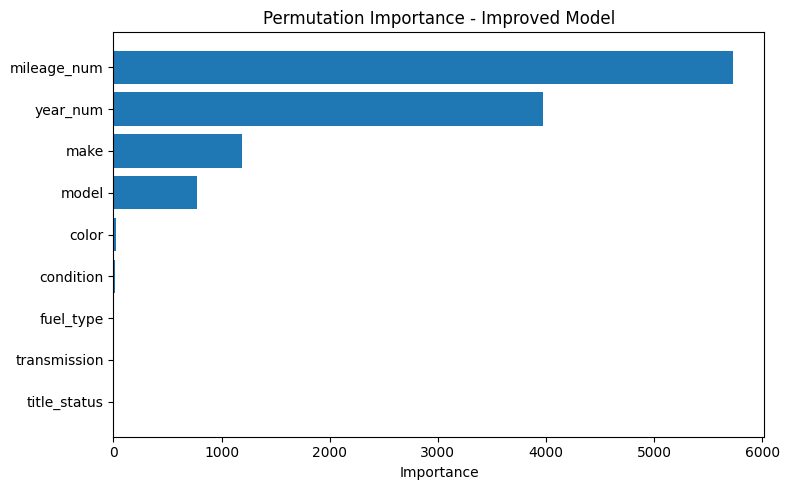

In [15]:
top_imp = importance_df.sort_values("importance_mean", ascending=True)

fig_permutation_importance, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_imp["feature"], top_imp["importance_mean"])
ax.set_title("Permutation Importance - Improved Model")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [16]:
import os

output_dir = '/content/myscrapers-qxa24002-v1/model_outputs'
os.makedirs(output_dir, exist_ok=True)
fig_permutation_importance.savefig(os.path.join(output_dir, 'permutation_importance.png'))
print(f"Permutation importance plot saved to '{os.path.join(output_dir, 'permutation_importance.png')}'")

Permutation importance plot saved to '/content/myscrapers-qxa24002-v1/model_outputs/permutation_importance.png'


#### Top 3 features after Permutation Importance

In [17]:
top3_features = importance_df.head(3)["feature"].tolist()
top3_features

['mileage_num', 'year_num', 'make']

## 2.Partial Dependence Plots for top 3 features:(production data/results)

In [18]:
# Picking the latest file available in results to create PDP charts
import os
latest_file = sorted(glob.glob("results/*-preds.csv"))[-1]
print(os.path.basename(latest_file))
res = pd.read_csv(latest_file)

2026040323-preds.csv


In [19]:
res["year_num"] = clean_numeric(res["year"]).astype(float)
res["mileage_num"] = clean_numeric(res["mileage"]).astype(float)

for col in improved_cat:
    if col not in res.columns:
        res[col] = np.nan

X_eval = res[improved_feats]

### PDP for mileage (production data)

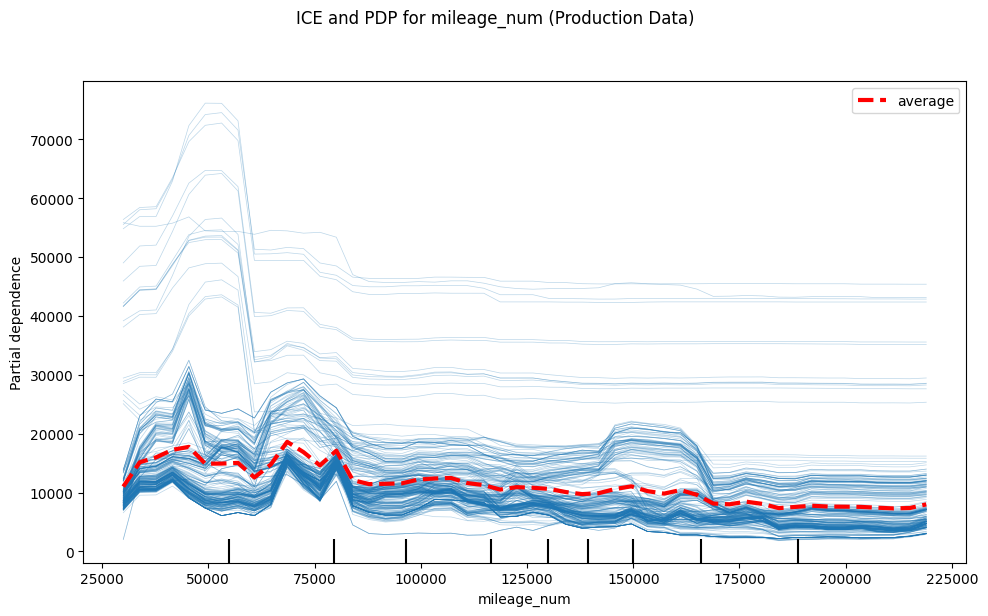

In [20]:
fig_mileage_pdp, ax = plt.subplots(figsize=(10, 6))
fig_mileage_pdp.suptitle('ICE and PDP for mileage_num (Production Data)', y=1.02)

PartialDependenceDisplay.from_estimator(
    best_improved_model,  # final model output
    X_eval,
    features=['mileage_num'],
    kind='both',
    pd_line_kw={'color': 'red', 'linestyle': '--', 'linewidth': 3},
    ax=ax,
    grid_resolution=50,
)
ax.set_ylabel('Predicted Price')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### PDP for year (production data)

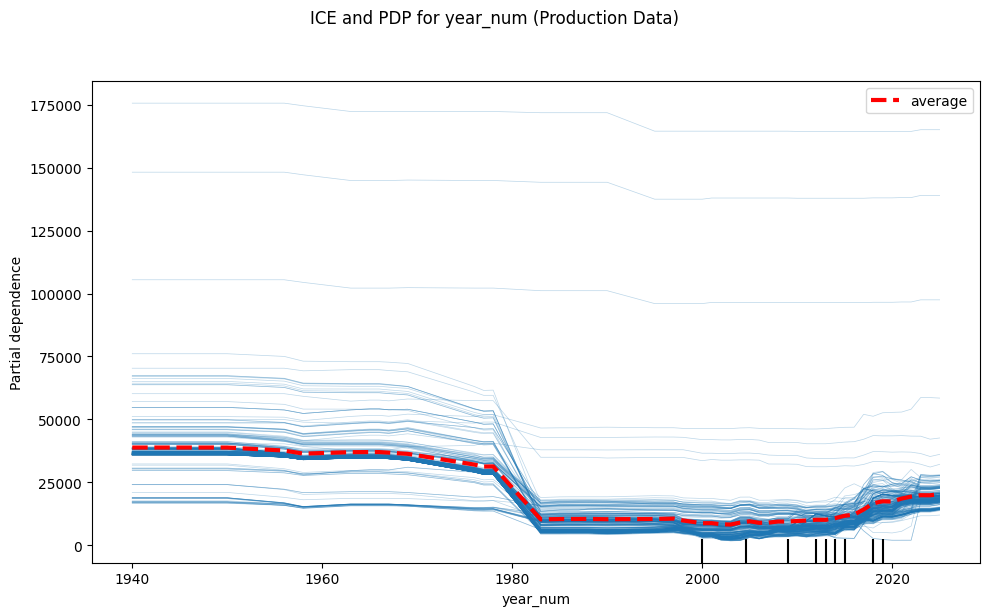

In [21]:
fig_year_pdp, ax = plt.subplots(figsize=(10, 6))
fig_year_pdp.suptitle('ICE and PDP for year_num (Production Data)', y=1.02)

PartialDependenceDisplay.from_estimator(
    best_improved_model,
    X_eval,
    features=['year_num'],
    kind='both',
    pd_line_kw={'color': 'red', 'linestyle': '--', 'linewidth': 3},
    ax=ax,
    grid_resolution=50,
)
ax.set_ylabel('Predicted Price')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### PDP for make (production data)

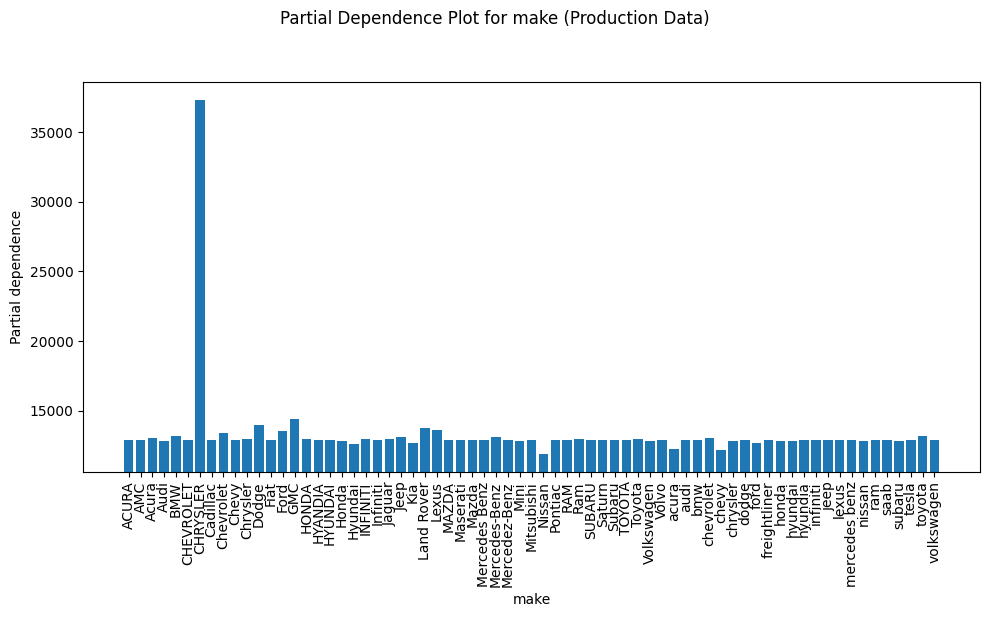

Avg. predicted price is taken as this is categorical variable


In [22]:
fig_make_pdp, ax = plt.subplots(figsize=(10, 6))
fig_make_pdp.suptitle('Partial Dependence Plot for make (Production Data)', y=1.02)

PartialDependenceDisplay.from_estimator(
    best_improved_model,
    X_eval,
    features=[('make')],
    categorical_features=improved_cat,
    ax=ax,
    grid_resolution=70,
    kind='average',
)
ax.set_ylabel('Predicted Price')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
print("Avg. predicted price is taken as this is categorical variable")

# Tracking performance as dataset grows

## Model Performance Trend Over Time

The following plot illustrates the trend of MAE for both the baseline and improved models, alongside the number of rows evaluated, as new data becomes available over different runs.

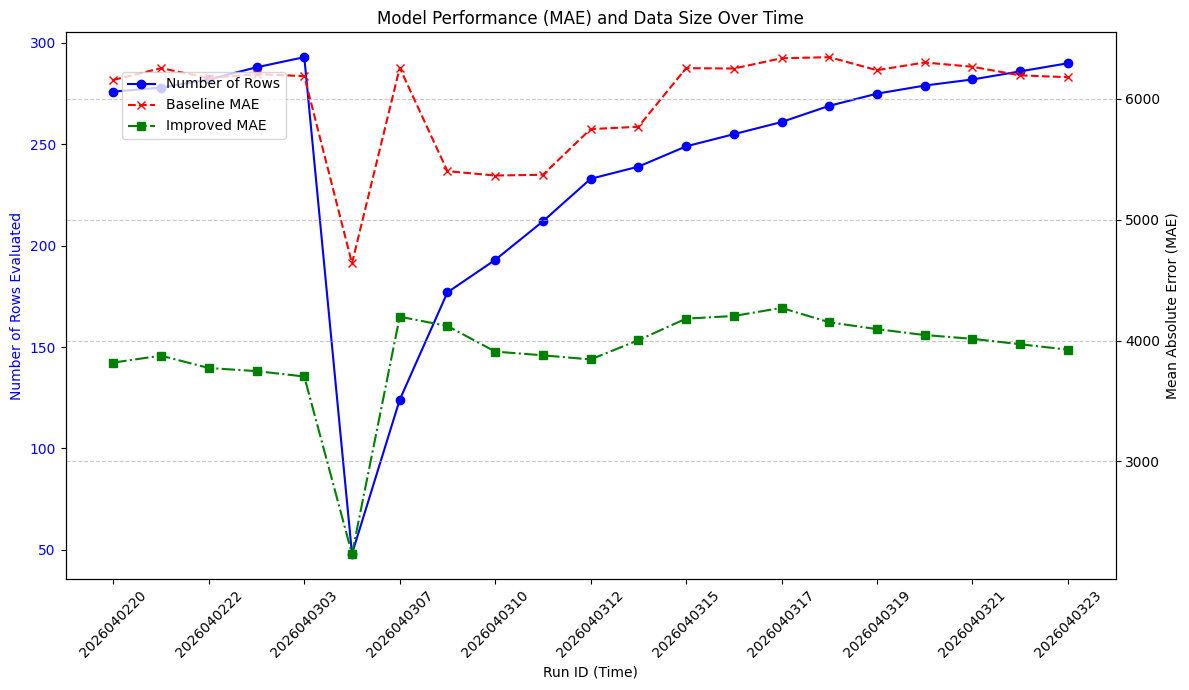

There is a sudden drop at runID 2026040305 because there is a sudden data drop at this point
The green line trend( improved MAE) shows a declining trend. That means model is improving over time.


In [23]:
fig_performance_trend, ax1 = plt.subplots(figsize=(12, 7))

# Plotting rows on the left y-axis
ax1.plot(trend_df['run_id'], trend_df['rows'], color='blue', label='Number of Rows', marker='o', linestyle='-')
ax1.set_xlabel('Run ID (Time)')
ax1.set_ylabel('Number of Rows Evaluated', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(trend_df['run_id'][::2]) # Show fewer x-axis labels if too crowded
ax1.tick_params(axis='x', rotation=45)

# Create a second y-axis for MAE values
ax2 = ax1.twinx()
ax2.plot(trend_df['run_id'], trend_df['baseline_MAE'], color='red', label='Baseline MAE', marker='x', linestyle='--')
ax2.plot(trend_df['run_id'], trend_df['improved_MAE'], color='green', label='Improved MAE', marker='s', linestyle='-.')
ax2.set_ylabel('Mean Absolute Error (MAE)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add title and legend
plt.title('Model Performance (MAE) and Data Size Over Time')
fig_performance_trend.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()
print("There is a sudden drop at runID 2026040305 because there is a sudden data drop at this point")
print("The green line trend( improved MAE) shows a declining trend. That means model is improving over time.")

## Cumulative Model Performance Trend Over Time

To better visualize the overall trend and smooth out run-to-run variations, let's look at the cumulative performance. This plot shows the cumulative number of rows processed and the cumulative average MAE for both models over time.

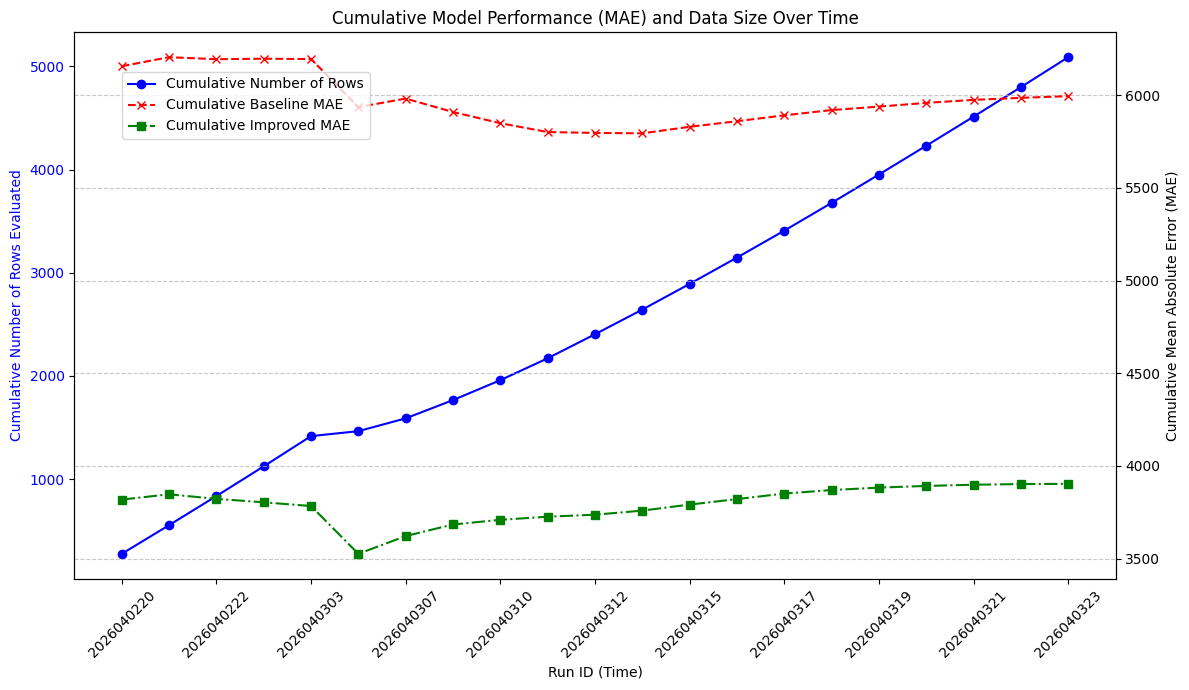

All plots saved to the '/content/myscrapers-qxa24002-v1/model_outputs' directory.


In [24]:
cumulative_df = trend_df.copy()
cumulative_df['cumulative_rows'] = cumulative_df['rows'].cumsum()
cumulative_df['cumulative_baseline_MAE'] = cumulative_df['baseline_MAE'].expanding().mean()
cumulative_df['cumulative_improved_MAE'] = cumulative_df['improved_MAE'].expanding().mean()

fig_cumulative_performance_trend, ax1 = plt.subplots(figsize=(12, 7))

# Plotting cumulative rows on the left y-axis
ax1.plot(cumulative_df['run_id'], cumulative_df['cumulative_rows'], color='blue', label='Cumulative Number of Rows', marker='o', linestyle='-')
ax1.set_xlabel('Run ID (Time)')
ax1.set_ylabel('Cumulative Number of Rows Evaluated', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(cumulative_df['run_id'][::2])
ax1.tick_params(axis='x', rotation=45)

# Create a second y-axis for cumulative MAE values
ax2 = ax1.twinx()
ax2.plot(cumulative_df['run_id'], cumulative_df['cumulative_baseline_MAE'], color='red', label='Cumulative Baseline MAE', marker='x', linestyle='--')
ax2.plot(cumulative_df['run_id'], cumulative_df['cumulative_improved_MAE'], color='green', label='Cumulative Improved MAE', marker='s', linestyle='-.')
ax2.set_ylabel('Cumulative Mean Absolute Error (MAE)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add title and legend
plt.title('Cumulative Model Performance (MAE) and Data Size Over Time')
fig_cumulative_performance_trend.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

import os

# Create the 'model_outputs' directory if it doesn't exist
output_dir = '/content/myscrapers-qxa24002-v1/model_outputs' # Corrected to absolute path
os.makedirs(output_dir, exist_ok=True)

# Save the PDP plots
fig_mileage_pdp.savefig(os.path.join(output_dir, 'pdp_mileage_num.png'))
fig_year_pdp.savefig(os.path.join(output_dir, 'pdp_year_num.png'))
fig_make_pdp.savefig(os.path.join(output_dir, 'pdp_make.png'))

# Save the model performance trend plots
fig_performance_trend.savefig(os.path.join(output_dir, 'model_performance_trend.png'))
fig_cumulative_performance_trend.savefig(os.path.join(output_dir, 'cumulative_model_performance_trend.png'))

print(f"All plots saved to the '{output_dir}' directory.")

#Insight on the model performance over time

The reason you see a slight increase in MAE over time instead of decrease:
1. For each run ID, there is only an addition of 1-2 rows each file.Also, the data volume is too low to predict the overall performance. With significant amount of additional data over time, this should decrease.
2. The additional features were also added very recently with LLM. For now, these features are only adding complexity. With time, additional features should provide improved prediction.
3. Overall the model is still performing better than baseline model by a high margin.

### Loading improved model outputs to model_output


In [25]:
predictions_df = pd.DataFrame({
    'actual_price': y_test,
    'predicted_price': best_improved_model.predict(X_test_imp)
})

output_filename = os.path.join(output_dir, 'improved_predictions.csv')
predictions_df.to_csv(output_filename, index=False)
print(f"Improved model predictions saved to '{output_filename}'")

Improved model predictions saved to '/content/myscrapers-qxa24002-v1/model_outputs/improved_predictions.csv'


#  Adding all the model output plots to Colab

### Adding all the plot outputs to git clone repo-output models folder inside colab only

In [26]:
import os

# Create the 'model_outputs' directory if it doesn't exist
# Use an absolute path to prevent nested folders
output_dir = '/content/myscrapers-qxa24002-v1/model_outputs'
os.makedirs(output_dir, exist_ok=True)

# Save the PDP plots
fig_mileage_pdp.savefig(os.path.join(output_dir, 'pdp_mileage_num.png'))
fig_year_pdp.savefig(os.path.join(output_dir, 'pdp_year_num.png'))
fig_make_pdp.savefig(os.path.join(output_dir, 'pdp_make.png'))

# Save the model performance trend plots
fig_performance_trend.savefig(os.path.join(output_dir, 'model_performance_trend.png'))
fig_cumulative_performance_trend.savefig(os.path.join(output_dir, 'cumulative_model_performance_trend.png'))

print(f"All plots saved to the '{output_dir}' directory.")

All plots saved to the '/content/myscrapers-qxa24002-v1/model_outputs' directory.


In [27]:
# Sanity check to ensure there are no nested repos
import shutil
import os

# Define the path to the incorrectly nested directory
incorrect_output_dir = '/content/myscrapers-qxa24002-v1/myscrapers-qxa24002-v1'

# Check if the directory exists and then remove it
if os.path.exists(incorrect_output_dir) and os.path.isdir(incorrect_output_dir):
    shutil.rmtree(incorrect_output_dir)
    print(f"Successfully deleted: {incorrect_output_dir}")
else:
    print(f"Directory not found or is not a directory: {incorrect_output_dir}")


Directory not found or is not a directory: /content/myscrapers-qxa24002-v1/myscrapers-qxa24002-v1


## Updating output plots from colab repo to github repo

In [28]:
# Import userdata for secure access to GitHub Token
from google.colab import userdata
import os

# Get GitHub Token from Colab Secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Configure Git with your user details (replace with your name and email)
!git config user.name 'Niharika Sharma(UCONN)'
!git config user.email 'qxa24002@uconn.edu'

# Navigate into the cloned repository directory
%cd /content/myscrapers-qxa24002-v1

# Add all changes, including the new model_outputs directory and its contents
!git add .

# Commit the changes
!git commit -m 'Add model performance plots and PDPs'
!git pull --rebase origin main
# Push the changes to GitHub using the PAT
# Make sure the remote origin is set correctly, e.g., https://github.com/YourGitHubUser/your-repo-name.git
!git push https://{GH_TOKEN}@github.com/OPIM5512-qxa24002/myscrapers-qxa24002-v1.git main

print("Changes pushed to GitHub. Please check your repository online.")

/content/myscrapers-qxa24002-v1
[main 67ec114] Add model performance plots and PDPs
 6 files changed, 13 insertions(+), 13 deletions(-)
 rewrite model_outputs/cumulative_model_performance_trend.png (98%)
 rewrite model_outputs/model_performance_trend.png (99%)
 rewrite model_outputs/pdp_make.png (98%)
 rewrite model_outputs/pdp_mileage_num.png (96%)
 rewrite model_outputs/pdp_year_num.png (97%)
From https://github.com/OPIM5512-qxa24002/myscrapers-qxa24002-v1
 * branch            main       -> FETCH_HEAD
Current branch main is up to date.
Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 517.84 KiB | 21.58 MiB/s, done.
Total 9 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/OPIM5512-qxa24002/myscrapers-qxa24002-v1.git
   a936a29..67ec114  main -> main
Changes pushed to GitHu